In [5]:
import geopandas as gpd
import rasterio
import os
os.getcwd()

'/mnt/c/Users/5302/PycharmProjects/geoid/notebooks'

In [12]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
print(BASE_DIR)

/mnt/c/Users/5302/PycharmProjects/geoid


In [13]:
points_path = BASE_DIR / "data" / "hydropost_Yablunytsia.gpkg"


In [20]:
gdf = gpd.read_file(points_path)
gdf = gdf.to_crs("EPSG:32635")  # КРИТИЧНО
gdf["geometry"] = gdf.geometry.apply(
    lambda g: g.geoms[0] if g.geom_type == "MultiPoint" else g
)


In [17]:
gdf.geom_type


0    MultiPoint
dtype: object

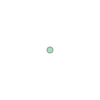

In [21]:
gdf.geometry.iloc[0]


In [22]:
print(gdf.geometry.x, gdf.geometry.y)


0    344322.217513
dtype: float64 0    5.320239e+06
dtype: float64


In [27]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

dem_paths = {
    "alos": BASE_DIR / "DATA_UTM" / "alos_dem_utm32635.tif",
    "aster": BASE_DIR / "DATA_UTM" / "aster_dem_utm32635.tif",
    "copernicus": BASE_DIR / "DATA_UTM" / "copernicus_dеm_utm32635.tif",  # ← кирилична е
    "fab": BASE_DIR / "DATA_UTM" / "fab_dem_utm32635.tif",
    "nasa": BASE_DIR / "DATA_UTM" / "nasa_dem_utm32635.tif",
    "srtm": BASE_DIR / "DATA_UTM" / "srtm_dem_utm32635.tif",
    "tan": BASE_DIR / "DATA_UTM" / "tan_dem_utm32635.tif",
}


In [28]:
for k, v in dem_paths.items():
    print(k, v.exists())


alos True
aster True
copernicus True
fab True
nasa True
srtm True
tan True


In [30]:
H_REP_BALT = 602.142
BALT_TO_EVRS = 0.105

H_REP_EVRS = H_REP_BALT + BALT_TO_EVRS
H_REP_EVRS

602.2470000000001

In [29]:
if not all(gdf.geom_type == "Point"):
    gdf["geometry"] = gdf.geometry.centroid

coords = [(p.x, p.y) for p in gdf.geometry]

for name, dem_path in dem_paths.items():
    with rasterio.open(dem_path) as ds:
        gdf[f"dem_{name}"] = [v[0] for v in ds.sample(coords)]

gdf


,id,H,index,max_level,min_level,max_Q,min_Q,basin,latitude,longitude,...,F_km2,name_station,geometry,dem_alos,dem_aster,dem_copernicus,dem_fab,dem_nasa,dem_srtm,dem_tan
0,1,602.142,42194,560,62,750.0,0.21,Дунай,48.016464,24.912328,...,552,Yablunytsya Hydrological Station,POINT (344322.218 5320238.816),598,588,597.523621,597.529602,598.834595,596,597.52179


In [ ]:
print(gdf[["dem_copernicus", "dem_srtm"]])


In [31]:
rep = 602.247  # EVRS
gdf["d_rep_minus_cop"] = rep - gdf["dem_copernicus"]
gdf["d_rep_minus_srtm"] = rep - gdf["dem_srtm"]


In [33]:
print(gdf)

   id        H  index  max_level  min_level  max_Q  min_Q  basin   latitude  \
0   1  602.142  42194        560         62  750.0   0.21  Дунай  48.016464   

   longitude  ...                        geometry  dem_alos  dem_aster  \
0  24.912328  ...  POINT (344322.218 5320238.816)       598        588   

  dem_copernicus     dem_fab    dem_nasa  dem_srtm    dem_tan  \
0     597.523621  597.529602  598.834595       596  597.52179   

   d_rep_minus_cop  d_rep_minus_srtm  
0         4.723389             6.247  

[1 rows x 35 columns]
